In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#visualization parameters
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("Libraries successfully imported!")

Libraries successfully imported!


In [2]:
df = pd.read_csv("SuperMarket Analysis.csv")
print("DATA LOADED SUCCESSFULLY")
# Display basic structural metadata
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("--- Dataframe Info ---")
print(df.info())
print("\n--- First 5 Rows ---")
print(df.head())

DATA LOADED SUCCESSFULLY
Dataset Shape: 1000 rows, 17 columns

--- Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object

In [4]:
print("--- Checking for Missing Values ---")
print(df.isnull().sum())

# Handle missing values in 'Sales' by replacing with the median of its specific product line
if df['Sales'].isnull().any():
    df['Sales'] = df.groupby('Product line')['Sales'].transform(lambda x: x.fillna(x.median()))
    print("\nMissing values filled using Product line-specific Medians.")

# Convert Date column to standard datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract useful time features for trend extraction
df['Year_Month'] = df['Date'].dt.to_period('M')
df['Day_of_Week'] = df['Date'].dt.day_name()

print("\nData preprocessing complete. Extracted 'Year_Month' and 'Day_of_Week'.")

--- Checking for Missing Values ---
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Data preprocessing complete. Extracted 'Year_Month' and 'Day_of_Week'.


In [6]:
print("--- Summary Statistics for Numeric Data ---")
print(df.describe().round(2))

# Compute key overall baseline data metrics
total_exp = df['Sales'].sum()
avg_exp = df['Sales'].mean()
median_exp = df['Sales'].median()

print("\n--- Baseline Financial Metrics ---")
print(f"Total Combined Expenditure: ${total_exp:,.2f}")
print(f"Average Outlay per Transaction: ${avg_exp:,.2f}")
print(f"Median Outlay per Transaction: ${median_exp:,.2f}")

--- Summary Statistics for Numeric Data ---
       Unit price  Quantity   Tax 5%    Sales                        Date  \
count     1000.00   1000.00  1000.00  1000.00                        1000   
mean        55.67      5.51    15.38   322.97  2019-02-14 00:05:45.600000   
min         10.08      1.00     0.51    10.68         2019-01-01 00:00:00   
25%         32.88      3.00     5.92   124.42         2019-01-24 00:00:00   
50%         55.23      5.00    12.09   253.85         2019-02-13 00:00:00   
75%         77.94      8.00    22.45   471.35         2019-03-08 00:00:00   
max         99.96     10.00    49.65  1042.65         2019-03-30 00:00:00   
std         26.49      2.92    11.71   245.89                         NaN   

          cogs  gross margin percentage  gross income   Rating  
count  1000.00                  1000.00       1000.00  1000.00  
mean    307.59                     4.76         15.38     6.97  
min      10.17                     4.76          0.51     4.00  
25

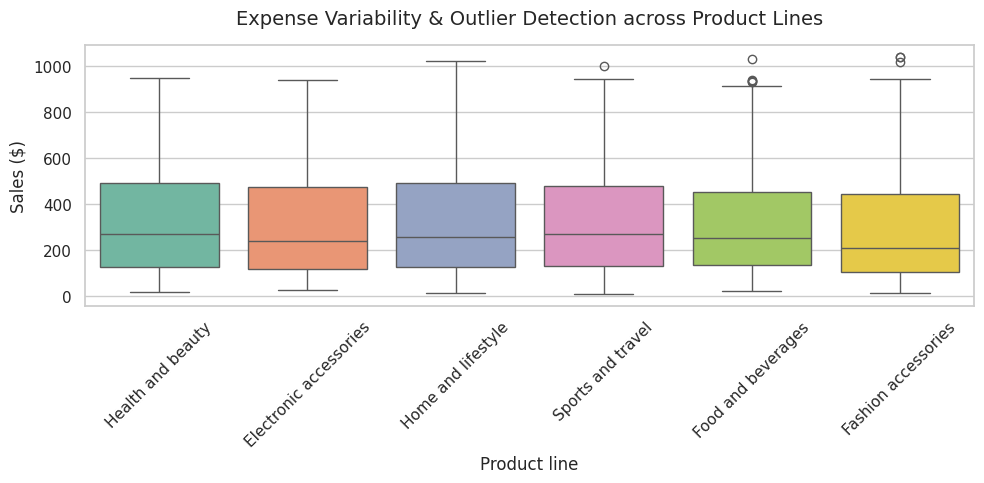

In [18]:
# 1. Distribution & Outlier Identification (Box plot)
plt.figure(figsize=(10, 5))
sns.boxplot(x='Product line', y='Sales', data=df, palette='Set2', hue='Product line', legend=False)
plt.title('Expense Variability & Outlier Detection across Product Lines', fontsize=14, pad=15)
plt.xticks(rotation=45)
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

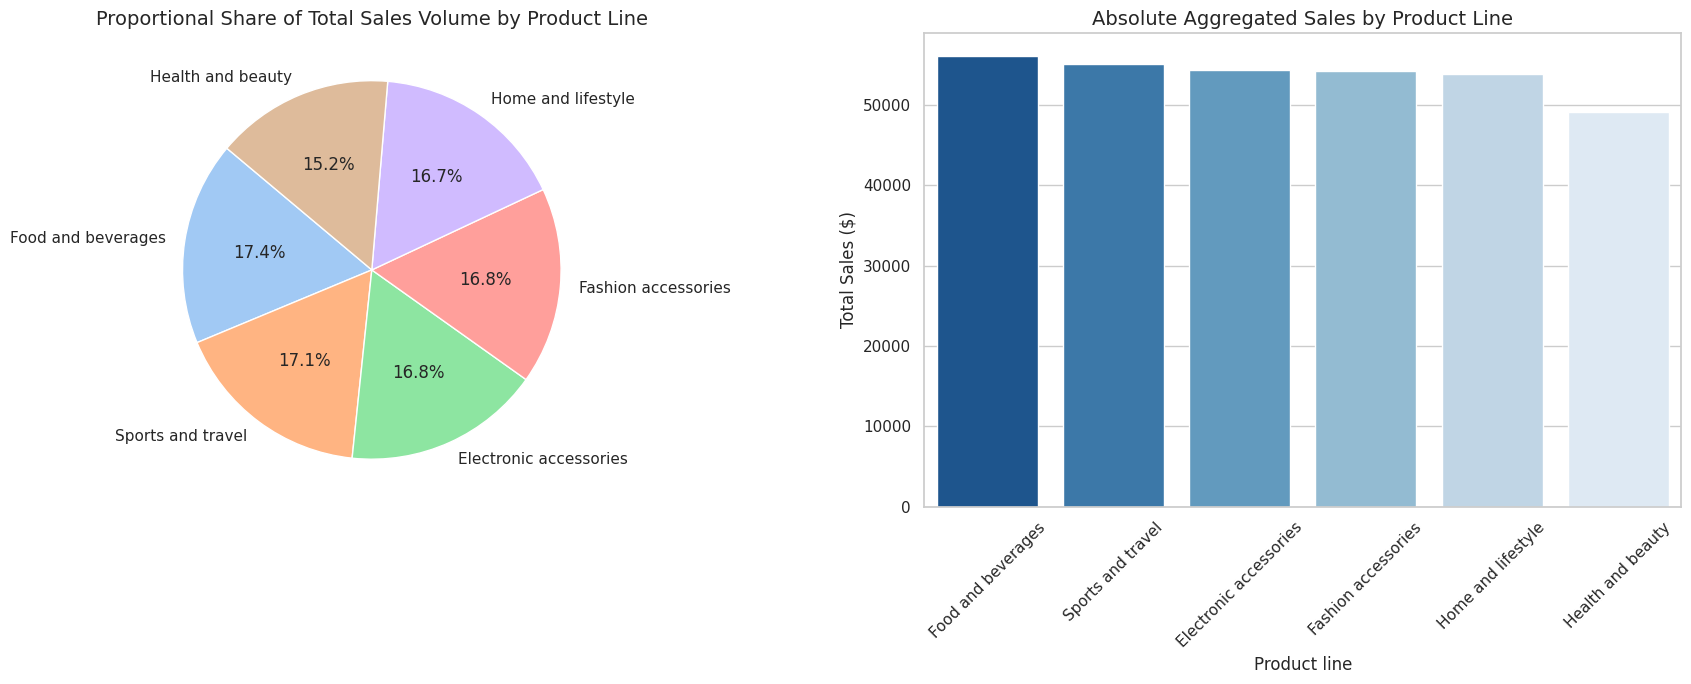

In [16]:
# 2. Product Line-Wise Aggregation (Pie & Bar charts)
prod_summary = df.groupby('Product line')['Sales'].agg(['sum', 'mean']).sort_values(by='sum', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
# Pie Chart for Total Proportional Volume Shares
axes[0].pie(prod_summary['sum'], labels=prod_summary.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[0].set_title('Proportional Share of Total Sales Volume by Product Line', fontsize=14)

# Bar Chart for Direct Numerical Comparison
sns.barplot(x=prod_summary.index, y=prod_summary['sum'], ax=axes[1], palette='Blues_r', hue=prod_summary.index, legend=False)
axes[1].set_title('Absolute Aggregated Sales by Product Line', fontsize=14)
axes[1].set_ylabel('Total Sales ($)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

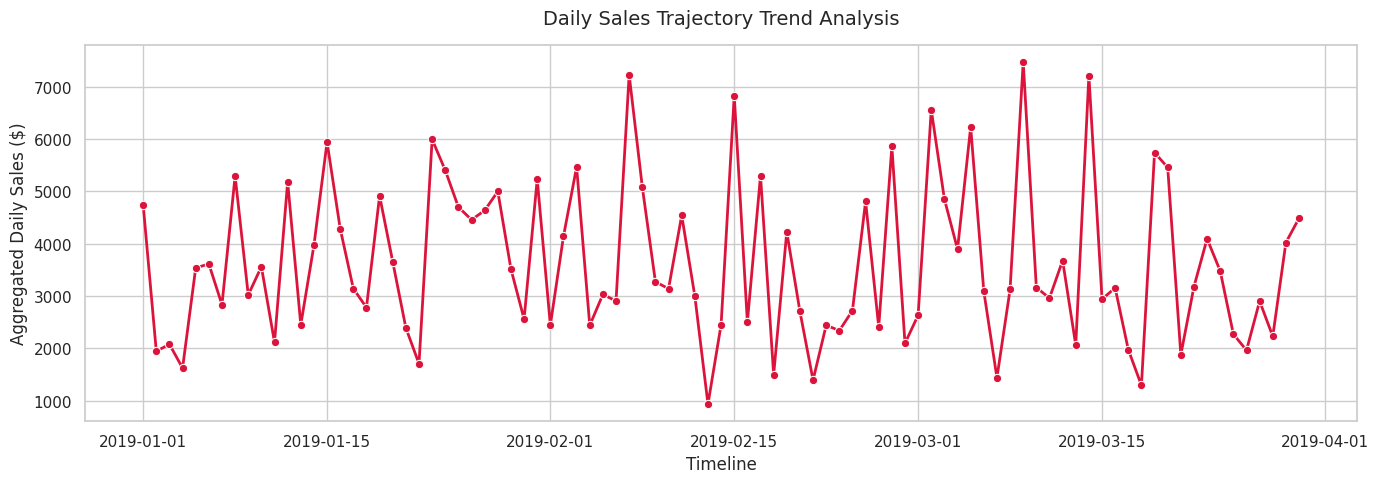

In [19]:
# 3. Trend Analysis Over Time (Line plot)
daily_trend = df.groupby('Date')['Sales'].sum().reset_index()
plt.figure(figsize=(14, 5))
sns.lineplot(x='Date', y='Sales', data=daily_trend, marker='o', color='crimson', linewidth=2)
plt.title('Daily Sales Trajectory Trend Analysis', fontsize=14, pad=15)
plt.xlabel('Timeline')
plt.ylabel('Aggregated Daily Sales ($)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3030/1626072062.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Day_of_Week', y='Sales', data=weekly_pattern, palette='viridis')


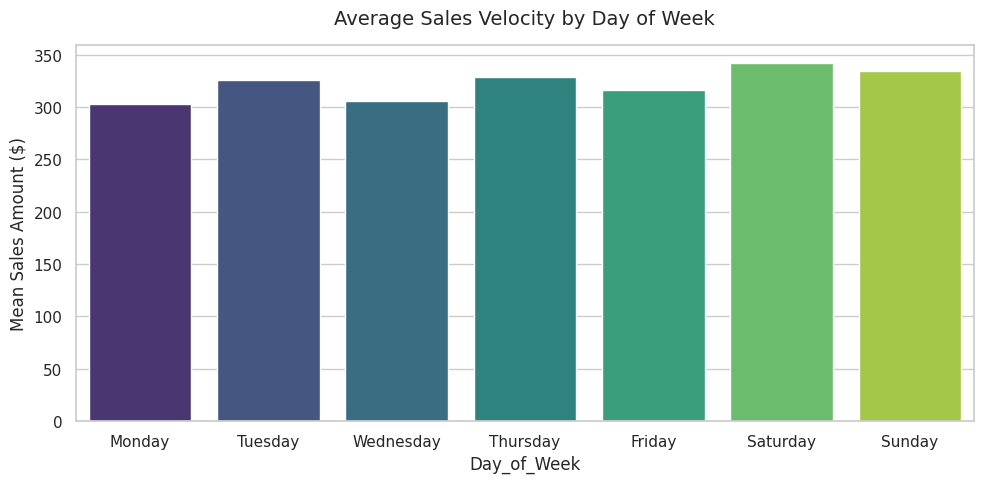

In [20]:
# 4. Weekly Behavioral Patterns
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_pattern = df.groupby('Day_of_Week')['Sales'].mean().reindex(day_order).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='Day_of_Week', y='Sales', data=weekly_pattern, palette='viridis')
plt.title('Average Sales Velocity by Day of Week', fontsize=14, pad=15)
plt.ylabel('Mean Sales Amount ($)')
plt.tight_layout()
plt.show()